**NOTE** This notebook is not part of the documentation. It's not meant to be in the webpage. It's something I wrote when I was testing the new functionality and I think it's nice to have it handy.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"

import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = bmb.load_data("sleepstudy")

In [3]:
data.head()

,Reaction,Days,Subject
0,249.5600,0,308
1,258.7047,1,308
2,250.8006,2,308
3,321.4398,3,308
4,356.8519,4,308


In [4]:
model = bmb.Model("Reaction ~ 1 + Days + (1 + Days | Subject)", data)
model

       Formula: Reaction ~ 1 + Days + (1 + Days | Subject)
        Family: gaussian
          Link: mu = identity
  Observations: 180
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 298.5079, sigma: 261.0092)
            Days ~ Normal(mu: 0.0, sigma: 48.8915)
        
        Group-level effects
            1|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 261.0092))
            Days|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 48.8915))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 56.1721)

In [5]:
idata = model.fit()

NUTS[nutpie]: [sigma, Days, Intercept_centered, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset]


Output()

In [6]:
df_new = data.head(10).reset_index(drop=True)
df_new["Subject"] = "xxx"
df_new = pd.concat([df_new, data.head(10)])
df_new = df_new.reset_index(drop=True)
df_new

,Reaction,Days,Subject
0,249.5600,0,xxx
1,258.7047,1,xxx
2,250.8006,2,xxx
3,321.4398,3,xxx
4,356.8519,4,xxx
5,414.6901,5,xxx
6,382.2038,6,xxx
7,290.1486,7,xxx
8,430.5853,8,xxx
9,466.3535,9,xxx


In [8]:
idata_new = model.predict(idata, data=df_new, inplace=False)

reaction_draws = idata_new.predictions["mu"]
mean = reaction_draws.mean(("chain", "draw")).to_numpy()
bounds = reaction_draws.quantile((0.025, 0.975), ("chain", "draw")).to_numpy()

Sampling: []


Output()

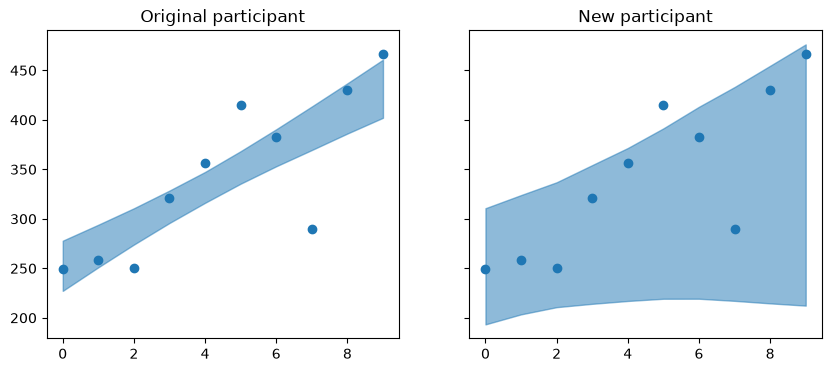

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].scatter(df_new.iloc[10:]["Days"], df_new.iloc[10:]["Reaction"])
axes[1].scatter(df_new.iloc[:10]["Days"], df_new.iloc[:10]["Reaction"])

axes[0].fill_between(
    np.arange(10), bounds[0, 10:], bounds[1, 10:], alpha=0.5, color="C0"
)
axes[1].fill_between(
    np.arange(10), bounds[0, :10], bounds[1, :10], alpha=0.5, color="C0"
)

axes[0].set_title("Original participant")
axes[1].set_title("New participant");

---

In [10]:
data = pd.read_csv("../../tests/data/crossed_random.csv")
data["subj"] = data["subj"].astype(str)
data.head()

,Unnamed: 0,subj,item,site,Y,continuous,dummy,threecats
0,0,0,0,0,0.276766,0.929616,0,a
1,1,1,0,0,-0.058104,0.008388,0,a
2,2,2,0,1,-6.847861,0.439645,0,a
3,3,3,0,1,12.474619,0.596366,0,a
4,4,4,0,2,-0.426047,0.709510,0,a


In [11]:
formula = "Y ~ 0 + threecats + (0 + threecats | subj)"
model = bmb.Model(formula, data)
model

       Formula: Y ~ 0 + threecats + (0 + threecats | subj)
        Family: gaussian
          Link: mu = identity
  Observations: 120
        Priors: 
    target = mu
        Common-level effects
            threecats ~ Normal(mu: [0. 0. 0.], sigma: [31.1617 31.1617 31.1617])
        
        Group-level effects
            threecats|subj ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: [31.1617 31.1617 31.1617]))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 5.8759)

In [12]:
idata = model.fit()

NUTS[nutpie]: [sigma, threecats, threecats|subj_sigma, threecats|subj_offset]


Output()

In [13]:
new_data = pd.DataFrame({"threecats": ["a", "a"], "subj": ["0", "11"]})
new_data

,threecats,subj
0,a,0
1,a,11


In [16]:
p1 = model.predict(idata, data=new_data, inplace=False)

Sampling: []


Output()

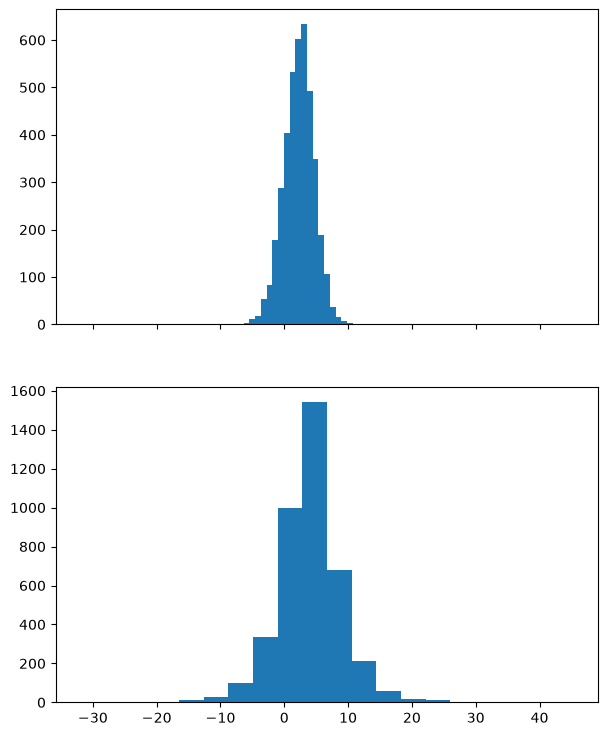

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

y1_grs = p1.predictions["mu"].sel(__obs__=0).to_numpy().flatten()
y2_grs = p1.predictions["mu"].sel(__obs__=1).to_numpy().flatten()

axes[0].hist(y1_grs, bins=20)
axes[1].hist(y2_grs, bins=20);

---

In [18]:
inhaler = pd.read_csv("../../tests/data/inhaler.csv")
inhaler["rating"] = pd.Categorical(inhaler["rating"], categories=[1, 2, 3, 4])
inhaler["treat"] = pd.Categorical(inhaler["treat"])

model = bmb.Model(
    "rating ~ 1 + period + treat + (1 + treat|subject)", inhaler, family="categorical"
)
idata = model.fit(tune=200, draws=200)

NUTS[nutpie]: [period, treat, Intercept_centered, 1|subject_sigma, 1|subject_offset, treat|subject_sigma, treat|subject_offset]


Output()

In [19]:
df_new = inhaler.head(2).reset_index(drop=True)
df_new["subject"] = [1, 999]
df_new

,subject,rating,treat,period,carry
0,1,1,0.5,0.5,0
1,999,1,0.5,0.5,0


In [23]:
p = model.predict(idata, data=df_new, inplace=False)

Sampling: []


Output()

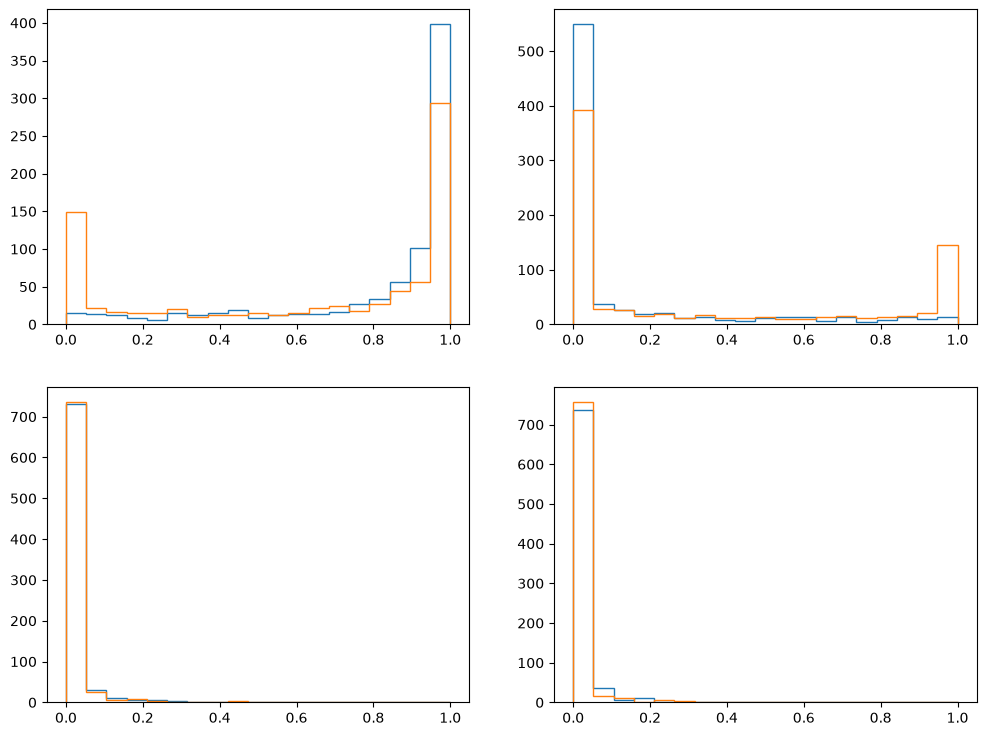

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
bins = np.linspace(0, 1, 20)

for i, ax in enumerate(axes.ravel()):
    x = p.predictions["p"].sel({"rating_dim": f"{i + 1}"}).to_numpy()
    ax.hist(x[..., 0].flatten(), bins=bins, histtype="step", color="C0")
    ax.hist(x[..., 1].flatten(), bins=bins, histtype="step", color="C1")